# K-Means++ on stocks
Same features and pipeline as `04_kmeans_clustering.ipynb` — only the centroid **initialization** changes.

**What it does differently:** instead of picking k random points, it picks the first centroid at random, then each next centroid with probability proportional to its squared distance from the closest centroid already chosen. Points far from existing centroids are more likely to get picked, so the starting centroids spread out across the data.

**The problem it solves:** plain K-Means' random init can start with centroids clumped together, which biases the whole run toward a worse local optimum. Distance-weighted seeding avoids that, so results are more consistent and reliable, with less need for many restarts. This is why scikit-learn defaults `init` to `"k-means++"`.

Load env vars and the cleaned data.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

load_dotenv(Path("..") / ".env")

CLEAN_PATH = Path("..") / os.environ["CLEAN_FLOORSHEET_PATH"]

df = pd.read_parquet(CLEAN_PATH)
df.shape

(47346001, 8)

Aggregate trades to one row per symbol — same as `04`.

In [2]:
stock_df = df.groupby("symbol").agg(
    total_trades=("transaction", "count"),
    total_turnover=("amount", "sum"),
    total_quantity=("quantity", "sum"),
    avg_rate=("rate", "mean"),
    std_rate=("rate", "std"),
    n_trading_days=("date", "nunique"),
)
stock_df.shape

(516, 6)

Distinct brokers per symbol (breadth of ownership).

In [3]:
broker_by_symbol = pd.concat([
    df[["symbol", "buyer"]].rename(columns={"buyer": "broker"}),
    df[["symbol", "seller"]].rename(columns={"seller": "broker"}),
])

stock_df["n_brokers"] = broker_by_symbol.groupby("symbol")["broker"].nunique()

In [4]:
stock_df["avg_trade_size"] = stock_df["total_turnover"] / stock_df["total_trades"]
stock_df["avg_daily_volume"] = stock_df["total_quantity"] / stock_df["n_trading_days"]

# coefficient of variation instead of raw std - price *levels* differ hugely across stocks
stock_df["price_cv"] = stock_df["std_rate"] / stock_df["avg_rate"]

stock_df.head()

,total_trades,total_turnover,total_quantity,avg_rate,std_rate,n_trading_days,n_brokers,avg_trade_size,avg_daily_volume,price_cv
symbol,,,,,,,,,,
ACLBSL,51401,3.117540e+09,2980523.0,1047.082955,176.869889,559,92,6.065135e+04,5331.883721,0.168917
ACLBSLP,3,1.333519e+07,23678.0,560.333333,50.639247,3,6,4.445064e+06,7892.666667,0.090373
ADBL,163871,1.080638e+10,32883528.0,323.707782,47.484528,561,92,6.594443e+04,58615.914439,0.146689
ADBLB,5,4.300000e+08,430000.0,1000.000000,0.000000,1,2,8.600000e+07,430000.000000,0.000000
ADBLB86,8,5.700000e+08,570000.0,1000.012500,0.035355,1,3,7.125000e+07,570000.000000,0.000035


Drop symbols with <30 trades — too thin to trust.

In [5]:
MIN_TRADES = 30
before = len(stock_df)

stock_df = stock_df[stock_df["total_trades"] >= MIN_TRADES].copy()

after = len(stock_df)
print(f"dropped {before - after} thinly-traded symbols ({before} -> {after})")

dropped 72 thinly-traded symbols (516 -> 444)


Final feature set for clustering.

In [6]:
feature_cols = [
    "total_trades",
    "total_turnover",
    "avg_trade_size",
    "avg_daily_volume",
    "n_brokers",
    "price_cv",
]

stock_df[feature_cols].describe()

,total_trades,total_turnover,avg_trade_size,avg_daily_volume,n_brokers,price_cv
count,4.440000e+02,4.440000e+02,4.440000e+02,4.440000e+02,444.000000,444.000000
mean,1.066336e+05,9.039479e+09,6.216798e+05,5.141406e+04,81.286036,0.136675
std,1.434250e+05,1.333607e+10,2.472409e+06,1.036078e+05,19.456189,0.081841
min,3.100000e+01,2.343786e+05,2.893563e+03,3.117241e+01,4.000000,0.001380
25%,2.614250e+03,3.926192e+08,5.666065e+04,5.562795e+03,79.750000,0.075240
50%,6.332500e+04,4.552992e+09,8.612347e+04,2.612231e+04,92.000000,0.122029
75%,1.594938e+05,1.268090e+10,1.445434e+05,5.726533e+04,92.000000,0.180314
max,1.650611e+06,1.073362e+11,2.932570e+07,1.534329e+06,92.000000,0.462778


Log-transform the skewed columns before scaling.

In [7]:
log_cols = ["total_trades", "total_turnover", "avg_trade_size", "avg_daily_volume"]

features = stock_df[feature_cols].copy()
features[log_cols] = np.log1p(features[log_cols])
features.head()

,total_trades,total_turnover,avg_trade_size,avg_daily_volume,n_brokers,price_cv
symbol,,,,,,
ACLBSL,10.847432,21.860310,11.012914,8.581647,92,0.168917
ADBL,12.006841,23.103403,11.096583,10.978779,92,0.146689
ADBLD83,6.990257,20.518515,13.529181,7.829735,69,0.033038
AHL,11.253455,22.112200,10.858777,9.386008,92,0.203313
AHPC,12.923085,24.348358,11.425286,12.403298,92,0.161010


Standard-scale so no feature dominates by units.

In [8]:
scaler = StandardScaler()
X = scaler.fit_transform(features)
X.shape

(444, 6)

Sweep k=2..8 with K-Means++ init, compare inertia (elbow) vs silhouette.

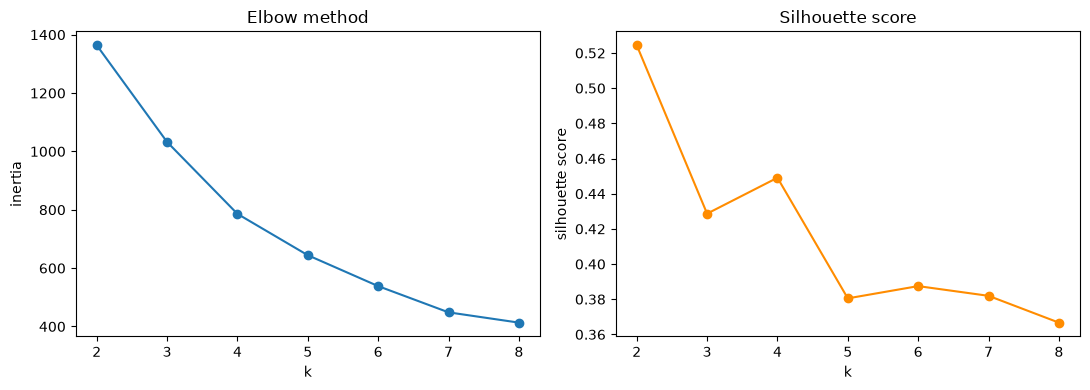

In [9]:
k_range = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertia")
axes[0].set_title("Elbow method")

axes[1].plot(list(k_range), silhouette_scores, marker="o", color="darkorange")
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouette score")
axes[1].set_title("Silhouette score")

fig.tight_layout()
plt.show()

In [10]:
best_k = list(k_range)[int(np.argmax(silhouette_scores))]
print(f"best k by silhouette score: {best_k}")

best k by silhouette score: 2


Fit the final model with k-means++ init.

In [11]:
kmeans = KMeans(n_clusters=best_k, init="k-means++", n_init=10, random_state=42)
stock_df["cluster"] = kmeans.fit_predict(X)

stock_df["cluster"].value_counts().sort_index()

cluster
0    112
1    332
Name: count, dtype: int64

PCA to 2D just to visualize the clusters.

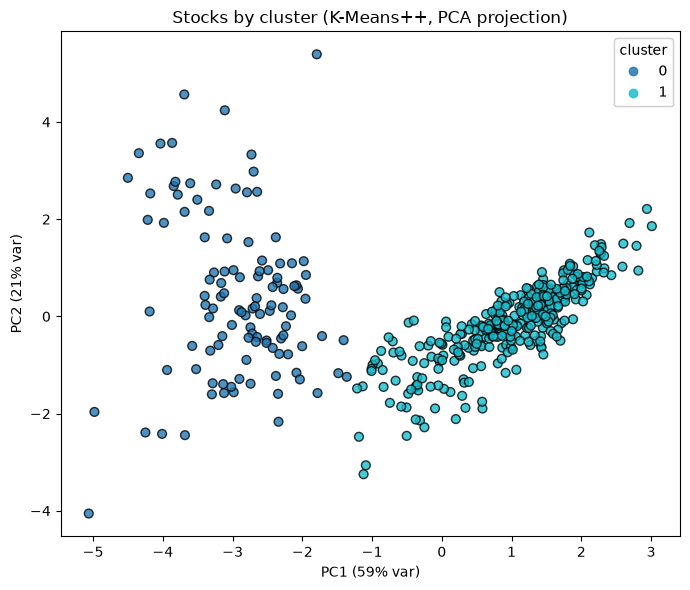

In [12]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(
    X_2d[:, 0], X_2d[:, 1], c=stock_df["cluster"], cmap="tab10", s=40, edgecolor="black", alpha=0.8
)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} var)")
ax.set_title("Stocks by cluster (K-Means++, PCA projection)")
legend = ax.legend(*scatter.legend_elements(), title="cluster")
ax.add_artist(legend)
fig.tight_layout()
plt.show()

Cluster profile: mean of raw features per cluster.

In [13]:
cluster_profile = stock_df.groupby("cluster")[feature_cols].mean().round(2)
cluster_profile["n_stocks"] = stock_df.groupby("cluster").size()
cluster_profile

,total_trades,total_turnover,avg_trade_size,avg_daily_volume,n_brokers,price_cv,n_stocks
cluster,,,,,,,
0,705.64,5.367612e+08,2235483.84,42213.88,52.62,0.07,112
1,142368.28,1.190787e+10,77263.95,54517.73,90.96,0.16,332


Top symbols per cluster — sanity check against real tickers.

In [14]:
for cluster_id, group in stock_df.groupby("cluster"):
    top_symbols = group["total_turnover"].sort_values(ascending=False).head(5)
    print(f"cluster {cluster_id} ({len(group)} stocks) top by turnover:")
    print(top_symbols)
    print()

cluster 0 (112 stocks) top by turnover:
symbol
HBLPO     4.105598e+09
NRICP     3.009332e+09
SBLD89    2.051582e+09
RBCLPO    2.034586e+09
UNL       1.890640e+09
Name: total_turnover, dtype: float64

cluster 1 (332 stocks) top by turnover:
symbol
HRL      1.073362e+11
NRN      8.827153e+10
NGPL     8.771513e+10
SHIVM    7.254203e+10
RADHI    6.843985e+10
Name: total_turnover, dtype: float64



Save the result as the recommended/canonical clustering output.

In [15]:
OUT_PATH = Path("..") / os.environ["DATA_PROCESSED_DIR"] / "stock_clusters.csv"
stock_df.to_csv(OUT_PATH)
print(f"Wrote {len(stock_df)} stock rows to {OUT_PATH}")

Wrote 444 stock rows to ../data/processed/stock_clusters.csv


## Summary
- Identical features, filtering, and k-selection as `04_kmeans_clustering.ipynb` — the only change is `init="k-means++"` instead of `init="random"`.
- K-Means++ seeds centroids using distance-weighted sampling instead of picking them purely at random, which avoids clumped starting centroids.
- That solves plain K-Means' main weakness: inconsistent results depending on the random draw.
- Result saved to `stock_clusters.csv` — this is the one to use downstream.